In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

import numpy as np
from scipy.stats import t
from scipy.stats import norm
from scipy.stats import ttest_rel
from numpy.linalg import inv
import warnings

sns.set_style('whitegrid')
warnings. filterwarnings('ignore')

def convert_pvalue(test, pvalue):
    if pvalue <= 0.01:
        return "{:.3f}***".format(test)
    elif pvalue <= 0.05:
        return "{:.3f}***".format(test)
    elif pvalue <= 0.1:
        return "{:.3f}***".format(test)
    return "{:.3f}".format(test)

# Read Data

## Male

In [2]:
df_M_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Husband Responses.dta')
df_M_raw = df_M_raw[(df_M_raw['A02_Sex'] == 'Male') & 
                    (df_M_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_M_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)
df_M_raw.tail()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A02_Sex,A03_Age,A04_Marital_status,...,Women__Production_Value,Respondent,HouseHold_AnimalUnits,Male_Owned_Livestock,Female_Owned_Livestock,ICV,Total_Physical_Assets_Naira,Total_Processing_Asset,Land_Operated_Cassava_Proportion,Land_Owned_Cassava_Proportion
735,4.0,43.0,4316.0,43163.0,431631.0,4316312.0,1.0,Male,63.0,married living with spouse/s,...,2500.0,Husband,3.00,0.20,1.00,0.0,346400.0,4.0,1.000000,0.500000
736,4.0,43.0,4317.0,43171.0,431711.0,4317111.0,1.0,Male,41.0,married living with spouse/s,...,1200.0,Husband,0.04,0.04,0.00,0.0,3396610.0,4.0,0.142857,0.454545
737,4.0,43.0,4318.0,43181.0,431811.0,4318111.0,1.0,Male,54.0,married living with spouse/s,...,800.0,Husband,0.00,0.00,0.00,1.0,12642980.0,4.0,0.654545,0.666667
738,4.0,43.0,4318.0,43182.0,431821.0,4318211.0,1.0,Male,72.0,married living with spouse/s,...,1900.0,Husband,1.70,1.00,0.70,0.0,11866180.0,4.0,0.428571,0.428571
739,4.0,43.0,4318.0,43182.0,431821.0,4318213.0,1.0,Male,42.0,married living with spouse/s,...,5400.0,Husband,0.50,0.36,0.14,1.0,1521870.0,4.0,0.333333,0.250000


## Female

In [3]:
df_F_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/Wife Responses.dta')
df_F_raw = df_F_raw[(df_F_raw['A02_Sex'] == 'Female') &
                    (df_F_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_F_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)
df_F_raw.tail()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A02_Sex,A03_Age,A04_Marital_status,...,Women__Production_Value,Respondent,HouseHold_AnimalUnits,Male_Owned_Livestock,Female_Owned_Livestock,ICV,Total_Physical_Assets_Naira,Total_Processing_Asset,Land_Operated_Cassava_Proportion,Land_Owned_Cassava_Proportion
773,4.0,43.0,4316.0,43163.0,431631.0,4316312.0,1.0,Female,48.0,married living with spouse/s,...,3600.0,Wife,2.40,1.00,1.40,0.0,185850.0,4.0,1.000000,1.000000
774,4.0,43.0,4317.0,43171.0,431711.0,4317111.0,1.0,Female,38.0,married living with spouse/s,...,5000.0,Wife,0.00,0.00,0.00,1.0,131700.0,4.0,1.000000,1.000000
775,4.0,43.0,4318.0,43181.0,431811.0,4318111.0,1.0,Female,40.0,married living with spouse/s,...,1100.0,Wife,0.00,0.00,0.00,1.0,2084000.0,4.0,0.654545,0.666667
776,4.0,43.0,4318.0,43182.0,431821.0,4318211.0,1.0,Female,49.0,married living with spouse/s,...,1600.0,Wife,0.72,0.46,0.26,1.0,603500.0,4.0,0.500000,0.000000
777,4.0,43.0,4318.0,43182.0,431821.0,4318213.0,1.0,Female,36.0,married living with spouse/s,...,300.0,Wife,0.52,0.20,0.32,1.0,2561050.0,4.0,0.500000,0.333333


## Mixing Male and Female

In [8]:
df_allMF = pd.concat([df_M_raw, df_F_raw]).reset_index(drop=True)
both_responses = (df_allMF['HouseID'].value_counts()).to_frame()
# print(both_responses)
both_responses = both_responses[both_responses['count']== 2]
df_allMF = df_allMF[df_allMF['HouseID'].isin(both_responses.index)]

df_M = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_M = df_M.reset_index(drop=True)

df_F = df_allMF[df_allMF['A02_Sex'] == 'Female']
df_F = df_F.reset_index(drop=True)

df_allMF['A02_Sex'].value_counts()

A02_Sex
Male      729
Female    729
Name: count, dtype: int64

In [9]:
df_H_dna = pd.read_csv("../Data/CMS-raw/dna.csv")
df_H_dna[df_H_dna['HouseID']==112115]

,ID,StateID,EnumerationID,HouseID,CassavaPlotInformationID,Fieldcode,Plotcode,adoption
6,7,11,11211,112115,1,1,1,0
7,8,11,11211,112115,2,2,1,0


In [28]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_dna = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_dna = df_H_dna[df_H_dna['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_H_dna.columns = ['HouseID', 'ZoneID', 'Household_ICV', 'planted']
df_H_dna['ZoneID'] = (df_H_dna['ZoneID']/10).astype(int)#.tail()
df_H_dna.head()

,HouseID,ZoneID,Household_ICV,planted
0,112115,1,0,0
1,112213,1,1,1
2,112214,1,2,1
3,113113,1,0,0
4,113115,1,0,0


In [11]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_livestock = pd.read_csv("../Data/CMS-raw/livestock_owned_all-regions.csv")
houseIDs = df_M['HouseID'].value_counts().keys()

df_H_livestock = df_H_livestock[df_H_livestock['HouseID'].isin(houseIDs)]
df_H_livestock = df_H_livestock.groupby('HouseID', as_index=False).agg({'Total_Number_of_livestk_owned': 'sum'})
df_H_livestock.columns = ['HouseID', 'HouseHold_AnimalUnits']

df_H_livestock.head()# ['Total_Number_of_livestk_owned'].equals(df_F['HouseHold_AnimalUnits'])

,HouseID,HouseHold_AnimalUnits
0,112115,31.0
1,112213,17.0
2,112214,82.0
3,113113,24.0
4,113115,56.0


## Household

In [12]:
originals = '../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/CMS (entire database)/Files/'
spouse = '../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/Spouse (wife)/'

houseIDs = df_M['HouseID'].value_counts().keys()

df_H_originals = pd.read_stata(originals+'Livestock_owned_All regions.dta')
df_H_spouse = pd.read_stata(spouse+'Livestock_owned_Spouse_All regions.dta')

df_H_originals = df_H_originals[df_H_originals['HouseID'].isin(houseIDs)]
df_H_originals = df_H_originals.groupby('HouseID', as_index=False).agg({'G01b_TNumber_owned': 'sum'})
df_H_originals.columns = ['HouseID', 'HouseHold_AnimalUnits']

df_H_spouse = df_H_spouse.groupby('HouseID', as_index=False).agg({'G01b_TNumber_owned': 'sum'})
df_H_spouse = df_H_spouse[df_H_spouse['HouseID'].isin(houseIDs)]
df_H_spouse.columns = ['HouseID', 'HouseHold_AnimalUnits']

df_H_originals[df_H_originals['HouseID'].isin([112115, 112213])]

,HouseID,HouseHold_AnimalUnits
0,112115.0,31.0
1,112213.0,17.0


In [13]:
df_H = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/CMS Responses.dta')
df_H = df_H[df_H['HouseID'].isin(df_allMF['HouseID'].value_counts().keys())]
df_H = df_H.reset_index(drop=True)
print(df_H.shape)

(729, 164)


**Assumption $df\_H \equiv df\_M$, therefore $y_H = y_M$ and $x_H = x_M$**

### Dependend variable

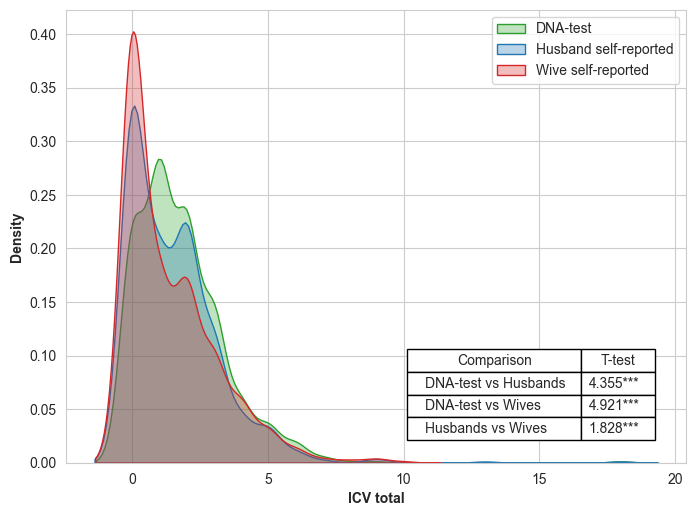

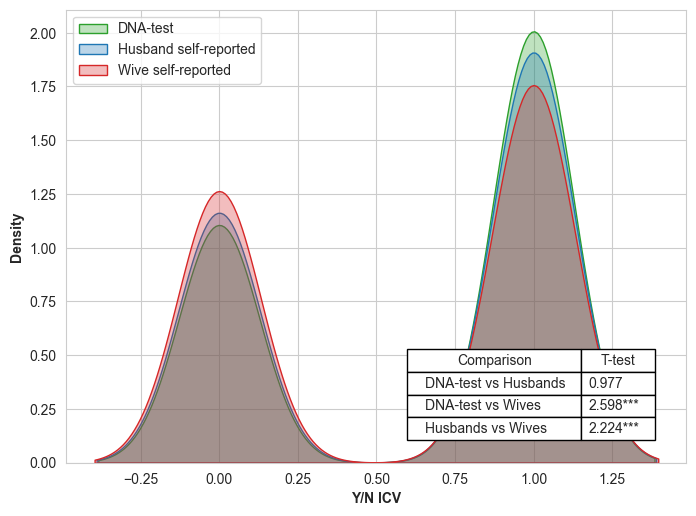

In [29]:
for index, var in enumerate(['Household_ICV', 'planted']):
    fig1, ax1 = plt.subplots(dpi=100, figsize=(8, 6))

    ttest_HM = ttest_rel(df_H_dna[f'{var}'], df_M[f'{var}'], nan_policy='omit')
    ttest_HF = ttest_rel(df_H_dna[f'{var}'], df_F[f'{var}'], nan_policy='omit')
    ttest_MF = ttest_rel(df_M[f'{var}'], df_F[f'{var}'], nan_policy='omit')

    data = []
    data.append(['DNA-test vs Husbands', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    data.append(['DNA-test vs Wives', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    data.append(['Husbands vs Wives', convert_pvalue(ttest_MF[0], ttest_MF[1])])

    df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])

    sns.kdeplot(df_H_dna[var], ax = ax1, fill=True, color="C2", label ="DNA-test",  alpha=0.3)
    sns.kdeplot(df_M[var], ax = ax1, fill=True, color="C0", label ="Husband self-reported",  alpha=0.3)
    sns.kdeplot(df_F[var], ax = ax1, fill=True, color="C3", label ="Wive self-reported",  alpha=0.3)
    ax1.set_xlabel(var)
    
    ax1.table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
              cellLoc='left', colWidths=[0.7, 0.3], bbox = (0.55, 0.05, 0.4, 0.2), loc='lower right', zorder=10)
    ax1.legend(loc=index+1)
    # ax1.set_title(labels[index])

    ax1.set_ylabel('Density', fontweight='bold')
    ax1.set_xlabel('Y/N ICV' if var == 'planted' else 'ICV total', fontweight='bold')
    
    fig1.savefig(f"../Output/Figures/{var}.png", dpi=100, bbox_inches='tight' )

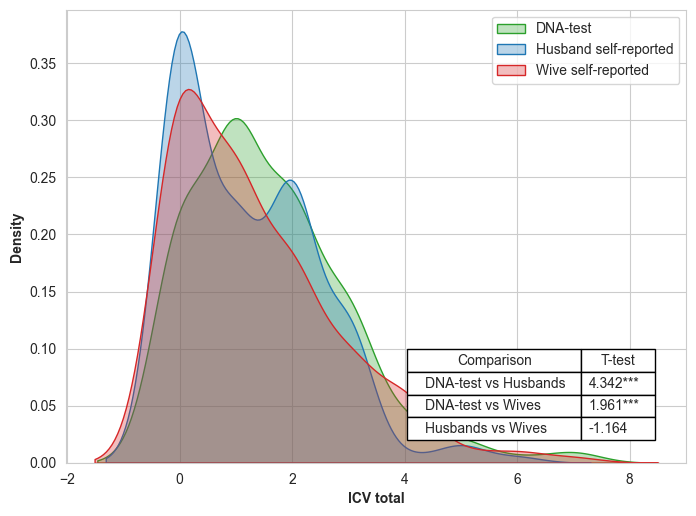

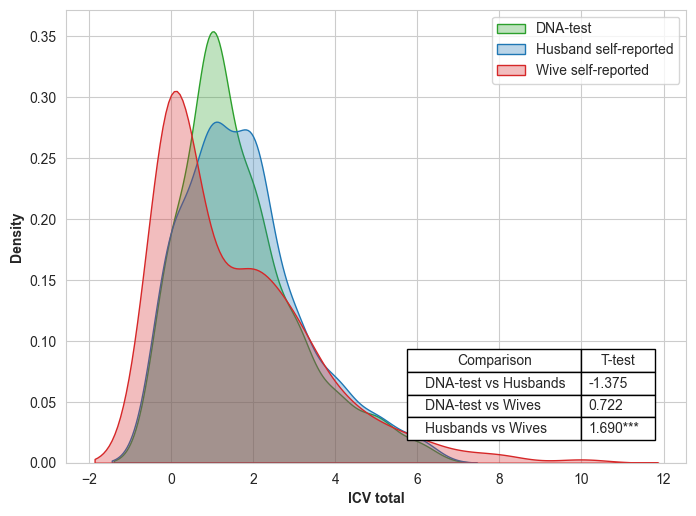

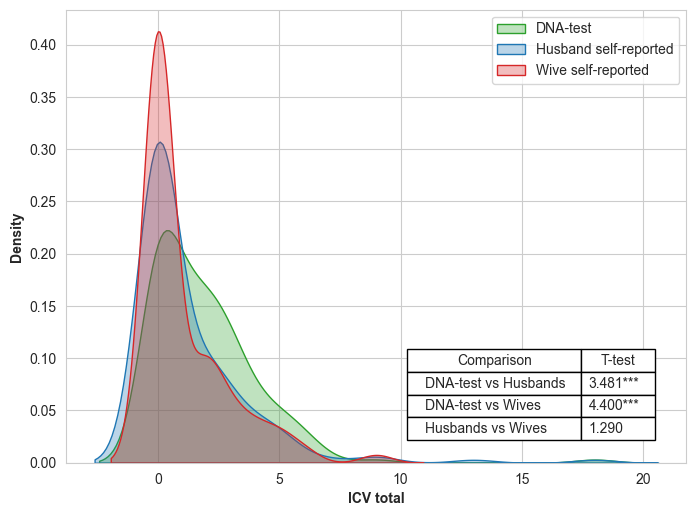

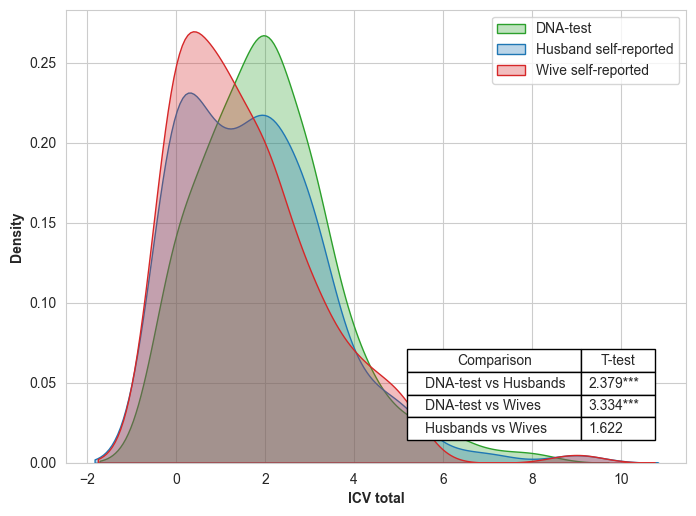

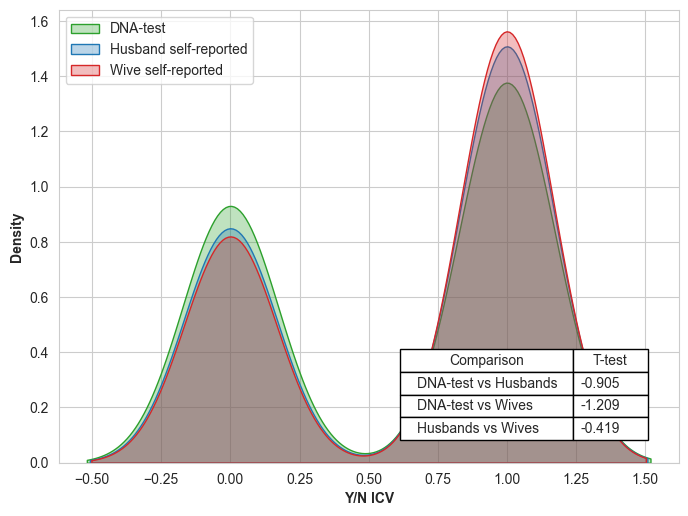

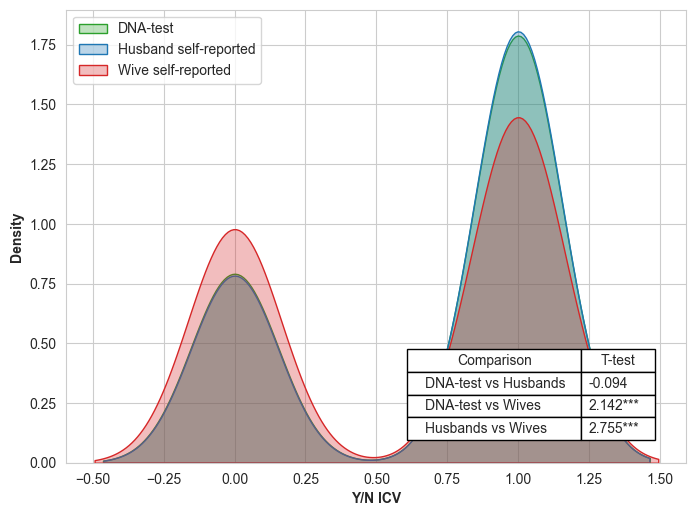

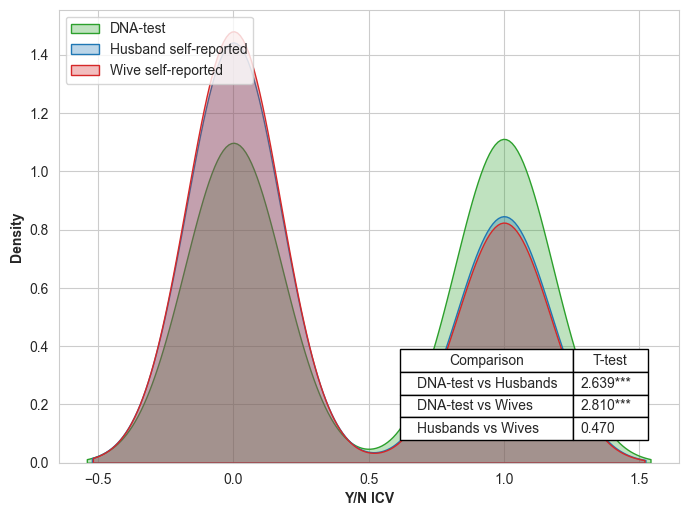

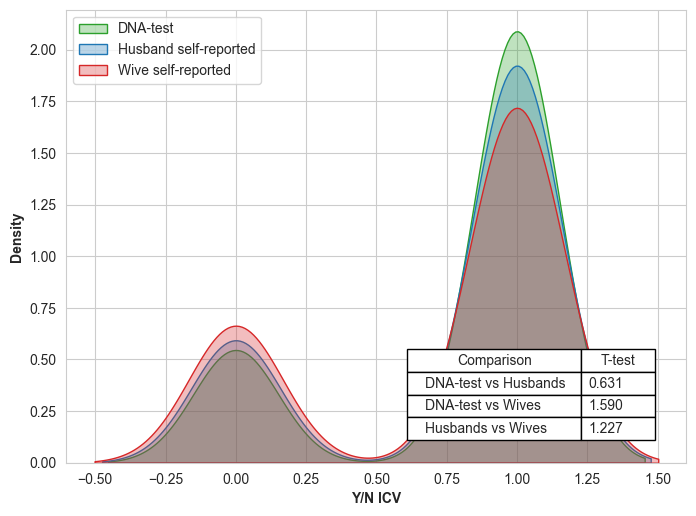

In [30]:
for index, var in enumerate(['Household_ICV', 'planted']):
    for zone in df_F['ZoneID'].unique():
        fig1, ax1 = plt.subplots(dpi=100, figsize=(8, 6))
        
        df_F_tmp = df_F[df_F['ZoneID'] == zone]
        df_M_tmp = df_M[df_M['ZoneID'] == zone]
        df_H_dna_tmp = df_H_dna[df_H_dna['ZoneID'] == zone]
        
        ttest_HM = ttest_rel(df_H_dna_tmp[f'{var}'], df_M_tmp[f'{var}'], nan_policy='omit')
        ttest_HF = ttest_rel(df_H_dna_tmp[f'{var}'], df_F_tmp[f'{var}'], nan_policy='omit')
        ttest_MF = ttest_rel(df_M_tmp[f'{var}'], df_F_tmp[f'{var}'], nan_policy='omit')
    
        data = []
        data.append(['DNA-test vs Husbands', convert_pvalue(ttest_HM[0], ttest_HM[1])])
        data.append(['DNA-test vs Wives', convert_pvalue(ttest_HF[0], ttest_HF[1])])
        data.append(['Husbands vs Wives', convert_pvalue(ttest_MF[0], ttest_MF[1])])
    
        df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])
    
        sns.kdeplot(df_H_dna_tmp[var], ax = ax1, fill=True, color="C2", label ="DNA-test",  alpha=0.3)
        sns.kdeplot(df_M_tmp[var], ax = ax1, fill=True, color="C0", label ="Husband self-reported",  alpha=0.3)
        sns.kdeplot(df_F_tmp[var], ax = ax1, fill=True, color="C3", label ="Wive self-reported",  alpha=0.3)
        ax1.set_xlabel(var)
        
        ax1.table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
                  cellLoc='left', colWidths=[0.7, 0.3], bbox = (0.55, 0.05, 0.4, 0.2), loc='lower right', zorder=10)
        ax1.legend(loc=index+1)
        # ax1.set_title(labels[index])
    
        ax1.set_ylabel('Density', fontweight='bold')
        ax1.set_xlabel('Y/N ICV' if var == 'planted' else 'ICV total', fontweight='bold')
        
        fig1.savefig(f"../Output/Figures/{var}_{zone}.png", dpi=100, bbox_inches='tight' )
    

### Independend variable

# T-paired test

In [13]:
df_H_livestock[df_H_livestock['HouseID'] == 112115]

,HouseID,HouseHold_AnimalUnits
0,112115,31.0


In [14]:
df_M.head()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A02_Sex,A03_Age,A04_Marital_status,...,Women__Production_Value,Respondent,HouseHold_AnimalUnits,Male_Owned_Livestock,Female_Owned_Livestock,ICV,Total_Physical_Assets_Naira,Total_Processing_Asset,Land_Operated_Cassava_Proportion,Land_Owned_Cassava_Proportion
0,1.0,11.0,112.0,1121.0,11211.0,112115.0,1.0,Male,48.0,married living with spouse/s,...,3228.0,Husband,1.10,0.70,0.4,0.0,1251992.0,2.0,0.181818,0.181818
1,1.0,11.0,112.0,1122.0,11221.0,112213.0,1.0,Male,60.0,married living with spouse/s,...,900.0,Husband,0.90,0.70,0.2,1.0,5471700.0,2.0,0.500000,0.000000
2,1.0,11.0,112.0,1122.0,11221.0,112214.0,1.0,Male,77.0,married living with spouse/s,...,0.0,Husband,3.40,3.40,0.0,1.0,7013400.0,2.0,0.333333,0.333333
3,1.0,11.0,113.0,1131.0,11311.0,113113.0,1.0,Male,65.0,married living with spouse/s,...,1800.0,Husband,0.96,0.36,0.6,1.0,6390300.0,1.0,0.166667,0.166667
4,1.0,11.0,113.0,1131.0,11311.0,113115.0,1.0,Male,45.0,married living with spouse/s,...,1000.0,Husband,1.60,0.40,1.2,0.0,2632500.0,1.0,0.141667,0.141667


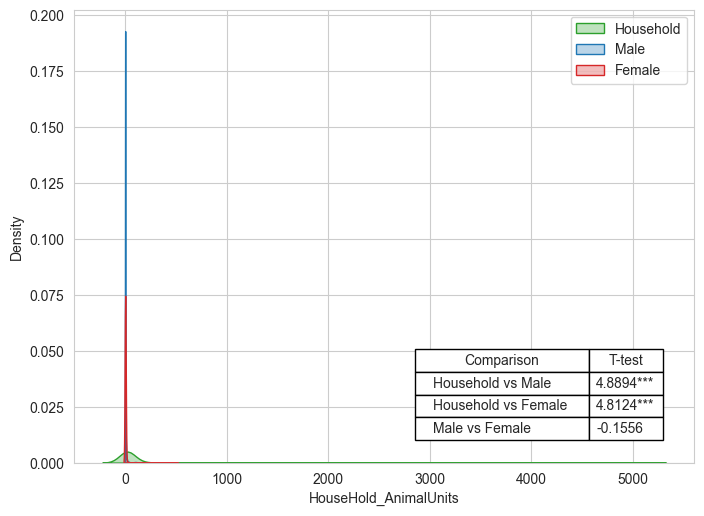

In [15]:
# ['Kids', 'HouseHold_AnimalUnits', 'Credit_Access', 'Shovel_Number_Own']:
for index, var in enumerate(['HouseHold_AnimalUnits']):
    fig1, ax1 = plt.subplots(dpi=100, figsize=(8, 6))

    ttest_HM = ttest_rel(df_H_livestock[f'{var}'], df_M[f'{var}'], nan_policy='omit')
    ttest_HF = ttest_rel(df_H_livestock[f'{var}'], df_F[f'{var}'], nan_policy='omit')
    ttest_MF = ttest_rel(df_M[f'{var}'], df_F[f'{var}'], nan_policy='omit')

    data = []
    data.append(['Household vs Male', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    data.append(['Household vs Female', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    data.append(['Male vs Female', convert_pvalue(ttest_MF[0], ttest_MF[1])])

    df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])

    sns.kdeplot(df_H_livestock[var], ax = ax1, fill=True, color="C2", label ="Household",  alpha=0.3)
    sns.kdeplot(df_M[var], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
    sns.kdeplot(df_F[var], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
    ax1.set_xlabel(var)
    
    ax1.table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
              cellLoc='left', colWidths=[0.7, 0.3], bbox = (0.55, 0.05, 0.4, 0.2), loc='lower right', zorder=10)
    ax1.legend(loc=index+1)

In [21]:
tvalues = {}
for var in df_H.keys()[17:]:
    if f'{var}' in df_M.keys() and f'{var}' in df_M.keys():
        try:
            #ttest_HM = ttest_rel(df_H[f'{var}'], df_M[f'{var}'], nan_policy='omit')
            # ttest_HF = ttest_rel(df_H[f'{var}'], df_F[f'{var}'], nan_policy='omit')
            ttest_MF = ttest_rel(df_M[f'{var}'], df_F[f'{var}'], nan_policy='omit')
            
            tvalues[var] = convert_pvalue(ttest_MF[0], ttest_MF[1])
            #if ttest_MF[1] <= 0.10:
            
            print(var, 
                  convert_pvalue(df_M[f'{var}'].mean(),1), 
                  convert_pvalue(df_F[f'{var}'].mean(),1),
                  convert_pvalue(ttest_MF[0], ttest_MF[1]))
        except:
            pass
            # print(f'Error in {var}')

Men_In_House 2.314 2.100 4.918***
Women_In_House 2.230 2.169 1.491
Kids 2.763 2.599 2.135***
Male_Managed 0.978 0.621 6.026***
Female_Managed 0.095 0.276 -5.875***
Joint_Managed 1.414 1.656 -3.276***
Male_ICV_Managed 0.647 0.313 7.146***
Female_ICV_Managed 0.063 0.167 -3.662***
Joint_ICV_Managed 0.801 0.909 -1.803***
Male_NonICV_Managed 0.331 0.309 0.484
Female_NonICV_Managed 0.032 0.108 -3.960***
Joint_NonICV_Managed 0.613 0.746 -2.456***
Household_ICV 1.512 1.390 1.828***
Household_NonICV 0.975 1.163 -3.160***
Household_Plots 2.506 2.565 -1.181
ICV_Plot_Size 9247.973 4552.396 6.253***
NonICV_Plot_Size 3436.019 3128.278 0.728
Male_ICV_PlotSize 4458.499 1109.005 6.470***
Female_ICV_PlotSize 214.768 429.746 -2.656***
Joint_ICV_PlotSize 4555.913 3013.645 2.504***
Male_NonICV_PlotSize 1485.806 908.609 1.855***
Female_NonICV_PlotSize 52.451 321.890 -2.185***
Joint_NonICV_PlotSize 1849.932 1811.525 0.140
House_Cassava_Plot_TotalSize 12683.992 7680.674 6.487***
Avg_Plot_Size 5988.399 3524.42